In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split

In [3]:
import seaborn as sns

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

In [5]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [6]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [7]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [8]:
df.shape    

(7043, 21)

In [9]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

19  TotalCharges      7043 non-null   str       
take this as a hint!!!

In [10]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
df["TotalCharges"].value_counts().tail()

TotalCharges
1990.5    1
7362.9    1
346.45    1
306.6     1
6844.5    1
Name: count, dtype: int64

In [12]:
(df["TotalCharges"] == "").sum()

np.int64(0)

In [13]:
totalcharges_numeric = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print(totalcharges_numeric.isna().sum())

11


In [14]:
problematic_rows = df[df["TotalCharges"].apply(
    lambda x: pd.isna(pd.to_numeric(x, errors="coerce"))
)]

problematic_rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [15]:
problematic_rows = df[totalcharges_numeric.isna()]

problematic_rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [16]:
df = df[~totalcharges_numeric.isna()]

In [17]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

In [18]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [19]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

In [20]:
df = df.reset_index(drop=True)

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  Paymen

In [22]:
# Count the number of customers in each class
print(df["Churn"].value_counts())

Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [23]:
# Count and percentage of each class
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [24]:
# churn column from categorical to numerical
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [25]:
df[["Churn"]].head()  

,Churn
0,0
1,0
2,1
3,0
4,1


In [26]:
print(df["Contract"].value_counts())

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64


In [27]:
df["Partner"] = df["Partner"].map({"Yes": 1, "No": 0})

In [28]:
df["Dependents"] = df["Dependents"].map({"Yes": 1, "No": 0})

In [29]:
df["DeviceProtection"] = df["DeviceProtection"].map({"Yes": 1, "No": 0})

In [30]:
# df["TechSupport"] = df["TechSupport"].map({"Yes": 1, "No": 0}) # problem!!!
df["StreamingTV"] = df["StreamingTV"].map({"Yes": 1, "No": 0})
df["StreamingMovies"] = df["StreamingMovies"].map({"Yes": 1, "No": 0})
df["PaperlessBilling"] = df["PaperlessBilling"].map({"Yes": 1, "No": 0})


In [31]:
df["TechSupport"] = df["TechSupport"].map(
    {
        "Yes": 1,
        "No": 0,
        "No internet service": 0
    }
)

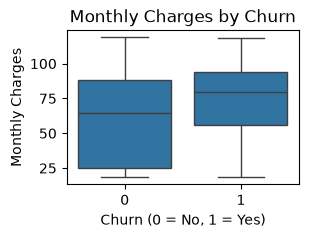

In [32]:
# Monthly Charges vs Churn
plt.figure(figsize=(3, 2))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Monthly Charges")
plt.show()

churn for bigger monthly costs

In [33]:
print(df["TotalCharges"].dtype)

float64


you could have reacted here ...


In [34]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

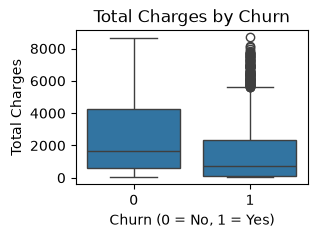

In [35]:
# Total Charges vs Churn
plt.figure(figsize=(3, 2))
sns.boxplot(x="Churn", y="TotalCharges", data=df)
plt.title("Total Charges by Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Total Charges")
plt.show()

churn for newer customers (probably, there is no date for subscription start) - but there is tenure - maybe corelated


In [36]:
df["tenure"].corr(df["TotalCharges"])

np.float64(0.8258804609332017)

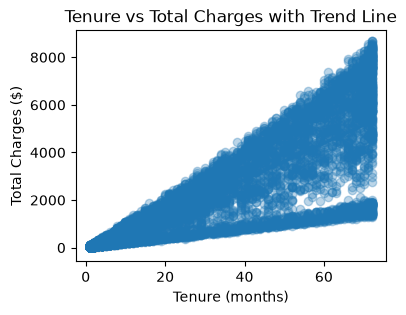

In [37]:
plt.figure(figsize=(4, 3))

sns.regplot(
    x="tenure",
    y="TotalCharges",
    data=df,
    scatter_kws={"alpha":0.3}
)

plt.title("Tenure vs Total Charges with Trend Line")
plt.xlabel("Tenure (months)")
plt.ylabel("Total Charges ($)")

plt.show()

In [38]:
df["gender"] = df["gender"].map({"Male": 1, "Female": 0})

In [39]:
print(df["gender"].value_counts())

gender
1    3549
0    3483
Name: count, dtype: int64


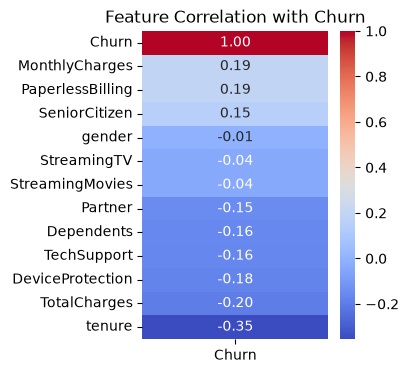

In [40]:
# Correlation of all numeric features with Churn
corr_with_churn = df.corr(numeric_only=True)[["Churn"]].sort_values(by="Churn", ascending=False)

plt.figure(figsize=(3, 4))
sns.heatmap(corr_with_churn,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Feature Correlation with Churn")
plt.show()

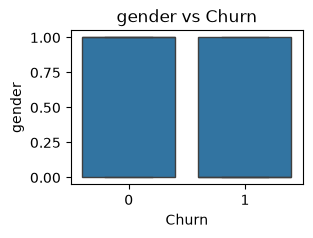

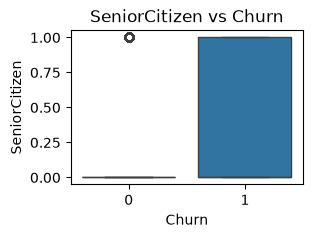

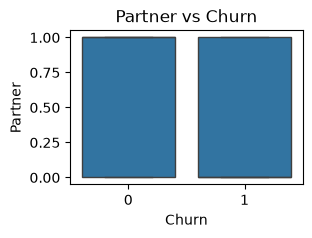

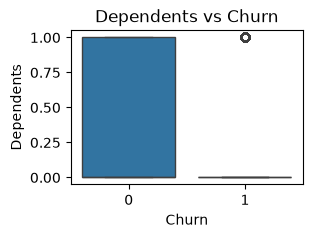

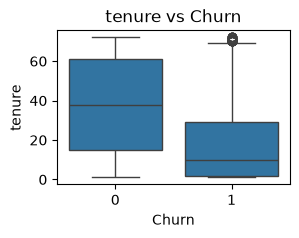

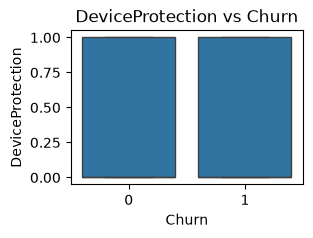

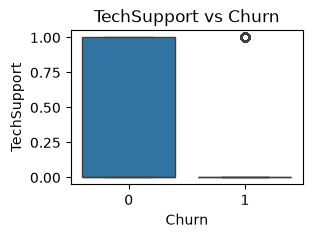

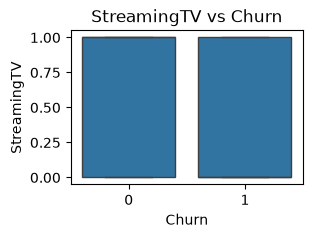

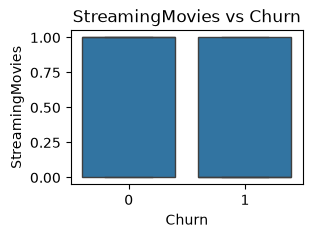

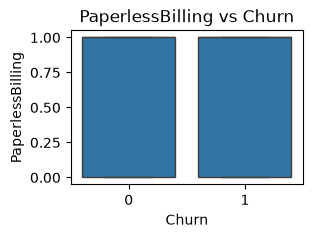

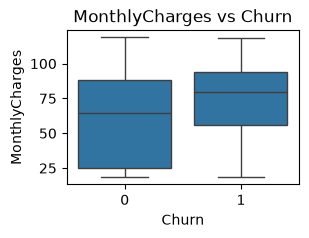

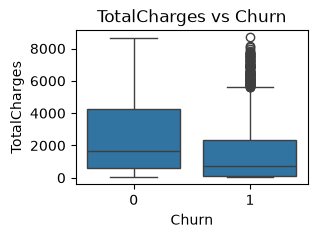

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select all numeric columns except the target
numeric_cols = df.select_dtypes(include=["number"]).columns.drop("Churn")

for col in numeric_cols:
    plt.figure(figsize=(3, 2))
    sns.boxplot(x="Churn", y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.show()

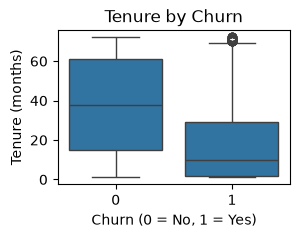

In [42]:
plt.figure(figsize=(3, 2))
sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Tenure by Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Tenure (months)")

plt.show()

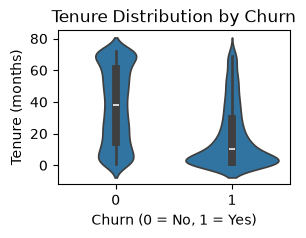

In [43]:
plt.figure(figsize=(3, 2))
sns.violinplot(x="Churn", y="tenure", data=df)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Tenure (months)")

plt.show()

In [44]:
print(df["InternetService"].unique())

<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str


In [45]:
print(df["InternetService"].value_counts())

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64


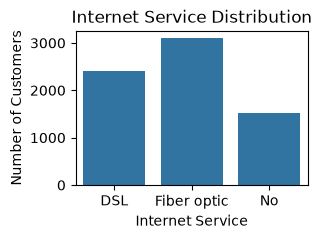

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(3, 2))
sns.countplot(x="InternetService", data=df)

plt.title("Internet Service Distribution")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

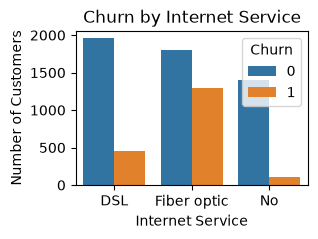

In [47]:
plt.figure(figsize=(3, 2))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

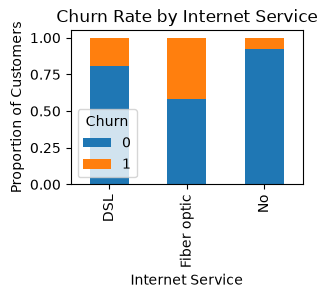

In [48]:
churn_rate = (
    pd.crosstab(df["InternetService"], df["Churn"], normalize="index")
)

churn_rate.plot(kind="bar", stacked=True, figsize=(3, 2))

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Proportion of Customers")
plt.legend(title="Churn")

plt.show()

In [49]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,No,No phone service,DSL,No,...,0.0,0,0.0,0.0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,Yes,No,DSL,Yes,...,1.0,0,0.0,0.0,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,Yes,No,DSL,Yes,...,0.0,0,0.0,0.0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,No,No phone service,DSL,Yes,...,1.0,1,0.0,0.0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,Yes,No,Fiber optic,No,...,0.0,0,0.0,0.0,Month-to-month,1,Electronic check,70.70,151.65,1


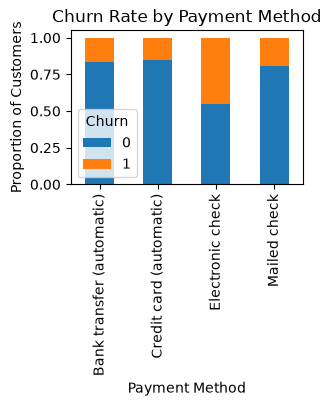

In [50]:
churn_rate = (
    pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index")
)

churn_rate.plot(kind="bar", stacked=True, figsize=(3, 2))

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Proportion of Customers")
plt.legend(title="Churn")

plt.show()

In [51]:
# one hot encoding for categorical variables

In [52]:
features = [
    "SeniorCitizen",
    "Dependents",
    "tenure",
    "TechSupport",
    "MonthlyCharges",
    "TotalCharges",
    "InternetService",
    "PaymentMethod"
]

df_model = df[features + ["Churn"]]

In [53]:
# One-hot encoding
df_model = pd.get_dummies(
    df_model,
    columns=["InternetService", "PaymentMethod"],
    drop_first=True
)

In [54]:
df_model.head()

,SeniorCitizen,Dependents,tenure,TechSupport,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,29.85,29.85,0,False,False,False,True,False
1,0,0,34,0,56.95,1889.50,0,False,False,False,False,True
2,0,0,2,0,53.85,108.15,1,False,False,False,False,True
3,0,0,45,1,42.30,1840.75,0,False,False,False,False,False
4,0,0,2,0,70.70,151.65,1,True,False,False,True,False


Models that usually need scaling
    normalize/standardize:

✅ KNN
✅ Logistic Regression
✅ Support Vector Machines (SVM)
✅ Neural Networks
✅ K-means clustering
✅ PCA

For these models, scaling is important.

Models that usually do NOT need scaling



✅ Decision Trees
✅ Random Forest
✅ Gradient Boosting (XGBoost, LightGBM, CatBoost)

Important: avoid data leakage

Do not scale before splitting.

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Create scaler
scaler = StandardScaler()

# Fit scaler only on training data
scaler.fit(X_train)

# Transform both training and test data
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

after scaling, X_train and X_test become NumPy arrays, so you lose column names. For learning this is fine, but later when using pipelines, many practitioners keep them as DataFrames or use Pipeline + ColumnTransformer to preserve structure. 

In [56]:
from sklearn.neighbors import KNeighborsClassifier

# Create KNN model with 5 neighbors
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [57]:
# Predict on training and test data
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)

print(f"Training predictions: {len(y_train_pred)}")
print(f"Test predictions: {len(y_test_pred)}")

Training predictions: 5625
Test predictions: 1407


In [58]:
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")

Accuracy : 0.759
Precision: 0.549
Recall   : 0.521


In [59]:
cm = confusion_matrix(y_test, y_test_pred)

print(cm)

[[873 160]
 [179 195]]


873 → correctly predicted customers who stayed

160 → predicted churn, but they stayed (False Positives)

179 → missed churners (False Negatives)

195 → correctly identified churners

In [60]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84      1033
           1       0.55      0.52      0.53       374

    accuracy                           0.76      1407
   macro avg       0.69      0.68      0.69      1407
weighted avg       0.76      0.76      0.76      1407



 precision - how often is prediction (for 'positive' output, this time churn) correct

 accuracy - % of correct prediction relevant to total

 recall - what procentage was predicted out of total 'positive' (churned)

 F1 - harmonic mean of precision and recall - both should be good


 --- relativly poor performance of the model, recall should be much better for this scenario, now only half of leaving customers are predicted



In [61]:
# try 7 neigbours
from sklearn.neighbors import KNeighborsClassifier


knn = KNeighborsClassifier(n_neighbors=7)

# Train the model
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [62]:
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")

Accuracy : 0.759
Precision: 0.549
Recall   : 0.521


In [63]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84      1033
           1       0.55      0.52      0.53       374

    accuracy                           0.76      1407
   macro avg       0.69      0.68      0.69      1407
weighted avg       0.76      0.76      0.76      1407



features for df_model should be changed

In [64]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [1, 3, 5, 7, 9, 11, 15]

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"K = {k:<2}  Accuracy = {accuracy:.3f}")

K = 1   Accuracy = 0.716
K = 3   Accuracy = 0.751
K = 5   Accuracy = 0.759
K = 7   Accuracy = 0.765
K = 9   Accuracy = 0.776
K = 11  Accuracy = 0.778
K = 15  Accuracy = 0.780


In [65]:
from sklearn.metrics import precision_score, recall_score

k_values = [1,3,5,7,9,11,15]

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    print(
        f"K={k:2d} | "
        f"Accuracy={accuracy_score(y_test,y_pred):.3f} | "
        f"Precision={precision_score(y_test,y_pred):.3f} | "
        f"Recall={recall_score(y_test,y_pred):.3f}"
    )

K= 1 | Accuracy=0.716 | Precision=0.470 | Recall=0.521
K= 3 | Accuracy=0.751 | Precision=0.534 | Recall=0.508
K= 5 | Accuracy=0.759 | Precision=0.549 | Recall=0.521
K= 7 | Accuracy=0.765 | Precision=0.567 | Recall=0.495
K= 9 | Accuracy=0.776 | Precision=0.591 | Recall=0.511
K=11 | Accuracy=0.778 | Precision=0.596 | Recall=0.516
K=15 | Accuracy=0.780 | Precision=0.603 | Recall=0.503


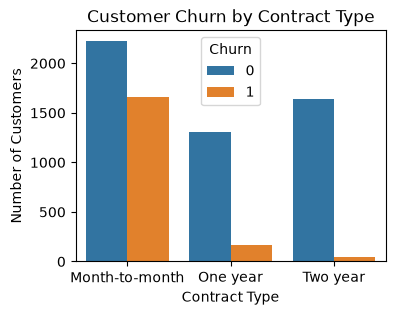

In [66]:
plt.figure(figsize=(4, 3))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

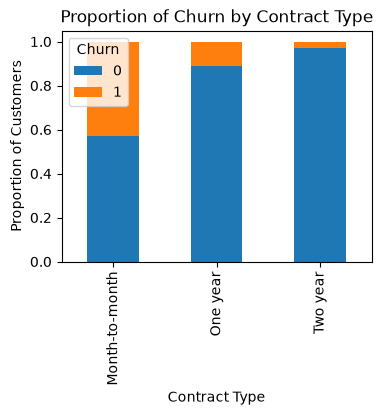

In [67]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
)

contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(4, 3)
)

plt.title("Proportion of Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Proportion of Customers")
plt.legend(title="Churn")

plt.show()

In [68]:
df = pd.get_dummies(df, columns=["Contract"], dtype=int)

In [69]:
features2 = [
    "SeniorCitizen",
    "Dependents",
    "tenure",
    "TechSupport",
    "MonthlyCharges",
    "Contract",
    "InternetService",
    "PaymentMethod"
]

df_model2 = df[features + ["Churn"]]

... TO BE CONTINUED

Exploratory analysis suggests that tenure, contract type, monthly charges, technical support, and internet service are among the most informative features for predicting churn

Future work could compare KNN with models such as Logistic Regression, Random Forest, or Gradient Boosting to improve both predictive performance and explainability